In [ ]:


import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.metrics import classification_report, confusion_matrix , ConfusionMatrixDisplay , roc_auc_score, roc_curve

sys.path.append(os.path.abspath('..'))

from src import loader ,get_preprocessor , models_pip , models_smote_pip

df =  loader()
preprocessor = get_preprocessor()

models = models_pip(preprocessor)
models = models_smote_pip(preprocessor)

In [ ]:

def roc_auc_plot(y_test, y_proba, model_name, ax=None):
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    threshold_target = 0.5
    idx = np.argmin(np.abs(thresholds - threshold_target))
    
    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
    ax.scatter(fpr[idx], tpr[idx], color='red', label=f'Threshold = {threshold_target}', zorder=5)
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(f"ROC Curve ({model_name})")
    ax.legend()

    return ax
        

def confusion_matrix_plot(pred , y_test , ax) : 
    cm = confusion_matrix(y_test , pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
    if ax is not None:
        disp.plot(ax=ax, values_format='.2f')
    else:
        disp.plot(values_format='.2f')

    

In [44]:
X = df.drop(columns=['Churn'])
Y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train , X_test , y_train , y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)

In [45]:
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64

/home/fangyuan/Projects/telco-customer-segmentation-churn/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


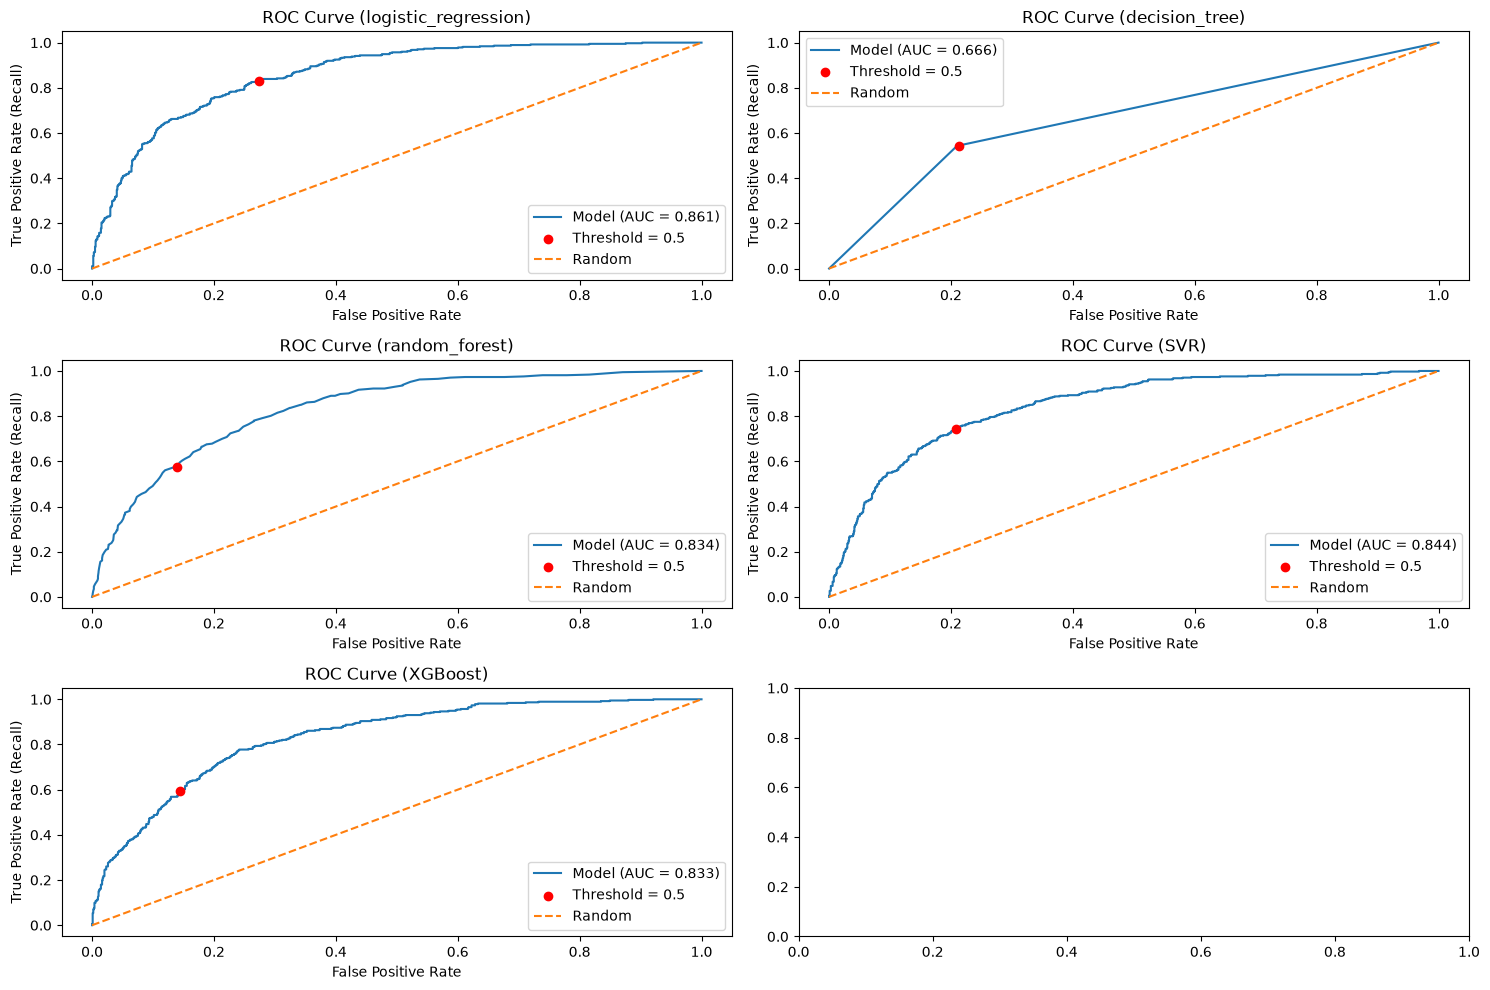

In [56]:
result = []
fig , axes = plt.subplots(3 , 2 , figsize=(15, 10))
for ax ,  (name , model) in zip(axes.flat , models.items()) : 
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0, 1, 100)

    # confusion_matrix_plot(y_pred , y_test , ax)
    roc_auc_plot(y_test , y_pred_proba , name , ax)

    scores = classification_report(y_test , y_pred, output_dict=True)

    # print(pd.DataFrame(scores))
    # break
    
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    result.append({
        "model": name,
        "accuracy": scores["accuracy"],
        "precision": scores['1']["precision"],
        "recall": scores["1"]["recall"],
        "f1_score": scores["1"]["f1-score"] , 
        "roc_auc": roc_auc,
    })

plt.tight_layout()


In [47]:
result_df = pd.DataFrame(
    result , 
    columns=['model' , 'accuracy' , 'precision' , 'recall' , 'f1_score', 'roc_auc']
) 
result_df.sort_values(by='roc_auc' , ascending=False , ignore_index=True)

,model,accuracy,precision,recall,f1_score,roc_auc
0,logistic_regression,0.754436,0.522843,0.828418,0.641079,0.860788
1,SVR,0.775727,0.556213,0.756032,0.640909,0.844178
2,random_forest,0.782825,0.592287,0.576408,0.584239,0.835555
3,XGBoost,0.786373,0.597297,0.592493,0.594886,0.833001
4,decision_tree,0.718240,0.472350,0.549598,0.508055,0.663843


In [48]:

# logistic_param = {
#     'classifier__C' : [0.01 , 0.1 , 1 , 10 , 100] , 
#     'classifier__solver': ['liblinear', 'saga'],
#     'classifier__max_iter' : [400 , 600 , 800 , 1000 , 1500], 
#     'classifier__class_weight' : [None , 'balanced']
# }

# random_forest_param = {
#     'classifier__n_estimators' : [100 , 200 , 300 , 400 , 500] , 
#     'classifier__max_depth' : [None , 5 , 10 , 15 , 20] , 
#     'classifier__min_samples_split' : [2 , 5 , 10] , 
#     'classifier__min_samples_leaf' : [1 , 2 , 4] ,
#     'classifier__class_weight' : [None , 'balanced']
# }

# xgb_param = {
#     'classifier__n_estimators' : [100 , 200 , 300 , 400 , 500] , 
#     'classifier__max_depth' : [3 , 5 , 7 , 9] , 
#     'classifier__learning_rate' : [0.01 , 0.1 , 0.2 , 0.3] ,
#     'classifier__subsample' : [0.5 , 0.7 , 1.0] ,
#     'classifier__colsample_bytree' : [0.5 , 0.7 , 1.0] ,
#     'classifier__scale_pos_weight' : [1 , 2 , 3 , 4 , 5]
# }

# logistic_cv = GridSearchCV(
#     estimator=models['logistic_regression'] , 
#     param_grid=logistic_param ,
#     cv=5 ,
#     scoring='roc_auc' , 
#     n_jobs=-1
# )

# random_forest_cv = GridSearchCV(
#     estimator=models['random_forest'] ,
#     param_grid=random_forest_param ,
#     cv=5 ,
#     scoring='roc_auc' ,
#     n_jobs=-1
# )

# xgb_cv = GridSearchCV(
#     estimator=models['XGBoost'] ,
#     param_grid=xgb_param ,
#     cv=5 ,
#     scoring='roc_auc' ,
#     n_jobs=-1
# )


In [49]:
# print('logistic regression training...')
# linear_model = logistic_cv.fit(X_train, y_train)

# print('random forest training...')
# random_forest_model = random_forest_cv.fit(X_train, y_train)

# print('XGBoost training...')
# xgb_model = xgb_cv.fit(X_train, y_train)

In [50]:
# result = [] 
# for model_name , model in zip(['logistic_regression' , 'random_forest' , 'XGBoost'] , [linear_model , random_forest_model , xgb_model]) :
#     y_pred = model.predict(X_test)
#     y_pred_proba = model.predict_proba(X_test)[:, 1]

#     scores = classification_report(y_test , y_pred, output_dict=True)

#     roc_auc = roc_auc_score(y_test , y_pred_proba)
#     result.append({
#         "model": model_name,
#         "accuracy": scores["accuracy"],
#         "precision": scores['1']["precision"],
#         "recall": scores["1"]["recall"],
#         "f1_score": scores["1"]["f1-score"], 
#         "roc_auc": roc_auc,
#     })

In [51]:
# result_df = pd.DataFrame(
#     result ,
#     columns=['model' , 'accuracy' , 'precision' , 'recall' , 'f1_score' , 'roc_auc']
# ).sort_values(by='roc_auc' , ascending=False , ignore_index=True)
# result_df